# Car Price Prediction

Objective:
Predict used car price using machine learning.

Dataset:
Quikr Used Car Dataset

Target:
Price

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"data/quikr_car.csv")

In [3]:
df.head(10)

,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing XO eRLX Euro III,Hyundai,2007,"80,000","45,000 kms",Petrol
1,Mahindra Jeep CL550 MDI,Mahindra,2006,"4,25,000",40 kms,Diesel
2,Maruti Suzuki Alto 800 Vxi,Maruti,2018,Ask For Price,"22,000 kms",Petrol
3,Hyundai Grand i10 Magna 1.2 Kappa VTVT,Hyundai,2014,"3,25,000","28,000 kms",Petrol
4,Ford EcoSport Titanium 1.5L TDCi,Ford,2014,"5,75,000","36,000 kms",Diesel
5,Ford EcoSport Titanium 1.5L TDCi,Ford,2015,Ask For Price,"59,000 kms",Diesel
6,Ford Figo,Ford,2012,"1,75,000","41,000 kms",Diesel
7,Hyundai Eon,Hyundai,2013,"1,90,000","25,000 kms",Petrol
8,Ford EcoSport Ambiente 1.5L TDCi,Ford,2016,"8,30,000","24,530 kms",Diesel
9,Maruti Suzuki Alto K10 VXi AMT,Maruti,2015,"2,50,000","60,000 kms",Petrol


In [4]:
df.tail(10)

,name,company,year,Price,kms_driven,fuel_type
882,Maruti Suzuki Alto 800 Select Variant,Maruti,2015,Ask For Price,"70,000 kms",Petrol
883,Maruti Suzuki Ritz VXI ABS,Maruti,2011,"2,70,000","50,000 kms",Petrol
884,tata zest 2017 f,tata,sale,"4,50,000",NaN,NaN
885,Tata Indica V2 DLE BS III,Tata,2009,"1,10,000","30,000 kms",Diesel
886,Toyota Corolla Altis,Toyota,2009,"3,00,000","1,32,000 kms",Petrol
887,Ta,Tara,zest,"3,10,000",NaN,NaN
888,Tata Zest XM Diesel,Tata,2018,"2,60,000","27,000 kms",Diesel
889,Mahindra Quanto C8,Mahindra,2013,"3,90,000","40,000 kms",Diesel
890,Honda Amaze 1.2 E i VTEC,Honda,2014,"1,80,000",Petrol,NaN
891,Chevrolet Sail 1.2 LT ABS,Chevrolet,2014,"1,60,000",Petrol,NaN


In [5]:
df.shape


(892, 6)

In [6]:
df.columns

Index(['name', 'company', 'year', 'Price', 'kms_driven', 'fuel_type'], dtype='object')

In [7]:
df.dtypes

name          object
company       object
year          object
Price         object
kms_driven    object
fuel_type     object
dtype: object

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 892 entries, 0 to 891
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        892 non-null    object
 1   company     892 non-null    object
 2   year        892 non-null    object
 3   Price       892 non-null    object
 4   kms_driven  840 non-null    object
 5   fuel_type   837 non-null    object
dtypes: object(6)
memory usage: 41.9+ KB


In [9]:
df.describe(include="all")


,name,company,year,Price,kms_driven,fuel_type
count,892,892,892,892,840,837
unique,525,48,61,274,258,3
top,Honda City,Maruti,2015,Ask For Price,"45,000 kms",Petrol
freq,13,235,117,35,30,440


In [10]:
df.sample(5)

,name,company,year,Price,kms_driven,fuel_type
632,Hyundai Elite i20 Sportz 1.2,Hyundai,2017,"5,50,000","15,000 kms",Petrol
144,Volkswagen Polo Comfortline 1.2L P,Volkswagen,2015,"3,99,999","2,800 kms",Petrol
276,Maruti Suzuki Maruti 800 Std,Maruti,2003,"57,000","56,758 kms",Petrol
592,Tata Indigo Marina LS,Tata,2004,"1,80,000","70,000 kms",Diesel
551,Maruti Suzuki Dzire ZXI,Maruti,2013,"3,80,000","35,000 kms",Petrol


In [11]:
df.isnull().sum()

name           0
company        0
year           0
Price          0
kms_driven    52
fuel_type     55
dtype: int64

In [12]:
df[df["kms_driven"].isnull()]

,name,company,year,Price,kms_driven,fuel_type
69,I want to sell my car Tata Zest,I,2017,Ask For Price,NaN,NaN
85,I want to sell my car Tata Zest,I,2017,Ask For Price,NaN,NaN
185,"Commercial , DZire LDI, 2016, for sale",Commercial,...,Ask For Price,NaN,NaN
195,"Tata indigo ecs LX, 201",Tata,150k,"1,50,000",NaN,NaN
206,MARUTI SUZUKI DESI,MARUTI,TOUR,"4,00,000",NaN,NaN
286,"Commercial , DZire LDI, 2016, for sale",Commercial,...,Ask For Price,NaN,NaN
294,Yama,Yamaha,r 15,"55,000",NaN,NaN
360,selling car Ta,selling,Zest,Ask For Price,NaN,NaN
368,Tata Zest 90,Tata,/-Rs,Ask For Price,NaN,NaN
385,Maruti Suzuki Swift Dzire car,Maruti,sale,"3,00,000",NaN,NaN


In [13]:
data = df.copy()

In [14]:
data.head()

,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing XO eRLX Euro III,Hyundai,2007,"80,000","45,000 kms",Petrol
1,Mahindra Jeep CL550 MDI,Mahindra,2006,"4,25,000",40 kms,Diesel
2,Maruti Suzuki Alto 800 Vxi,Maruti,2018,Ask For Price,"22,000 kms",Petrol
3,Hyundai Grand i10 Magna 1.2 Kappa VTVT,Hyundai,2014,"3,25,000","28,000 kms",Petrol
4,Ford EcoSport Titanium 1.5L TDCi,Ford,2014,"5,75,000","36,000 kms",Diesel


# **EDA**

## Price col cleaning

In [15]:
data["Price"].unique()

array(['80,000', '4,25,000', 'Ask For Price', '3,25,000', '5,75,000',
       '1,75,000', '1,90,000', '8,30,000', '2,50,000', '1,82,000',
       '3,15,000', '4,15,000', '3,20,000', '10,00,000', '5,00,000',
       '3,50,000', '1,60,000', '3,10,000', '75,000', '1,00,000',
       '2,90,000', '95,000', '1,80,000', '3,85,000', '1,05,000',
       '6,50,000', '6,89,999', '4,48,000', '5,49,000', '5,01,000',
       '4,89,999', '2,80,000', '3,49,999', '2,84,999', '3,45,000',
       '4,99,999', '2,35,000', '2,49,999', '14,75,000', '3,95,000',
       '2,20,000', '1,70,000', '85,000', '2,00,000', '5,70,000',
       '1,10,000', '4,48,999', '18,91,111', '1,59,500', '3,44,999',
       '4,49,999', '8,65,000', '6,99,000', '3,75,000', '2,24,999',
       '12,00,000', '1,95,000', '3,51,000', '2,40,000', '90,000',
       '1,55,000', '6,00,000', '1,89,500', '2,10,000', '3,90,000',
       '1,35,000', '16,00,000', '7,01,000', '2,65,000', '5,25,000',
       '3,72,000', '6,35,000', '5,50,000', '4,85,000', '3,29,5

In [16]:
"4,50,000".replace(",", "")

'450000'

In [17]:
data = data[data["Price"] != "Ask For Price"]

In [18]:
data.shape

(857, 6)

In [19]:
data["Price"] = data["Price"].str.replace(",", "")

In [20]:
data["Price"] = data["Price"].astype(int)

In [21]:
data["Price"].dtype

dtype('int64')

## Cleaning year Column

In [22]:
data["year"].unique()

array(['2007', '2006', '2014', '2012', '2013', '2016', '2015', '2010',
       '2017', '2008', '2018', '2011', '2019', '2009', '2005', '2000',
       '150k', 'TOUR', '2003', 'r 15', '2004', 'sale', '1995', 'ara)',
       '2002', 'SELL', '2001', 'tion', 'odel', '2 bs', 'arry', 'o...',
       'Zest', 'ture', 'emi', 'car', 'able', 'd...', 'SALE', 'sell',
       'd Ex', 'n...', 'e...', 'go .', 'k...', 'o c4', 'zire', 'Sumo',
       'cab', 'EV2', 'r...', 'zest'], dtype=object)

In [23]:
data["year"].str.isnumeric().value_counts()

year
True     819
False     38
Name: count, dtype: int64

In [24]:
data = data[data["year"].str.isnumeric()]

In [25]:
data["year"] = data["year"].astype(int)

In [26]:
data["year"].dtype

dtype('int64')

In [27]:
data.shape

(819, 6)

## Cleaning kms_driven

In [28]:
data["kms_driven"].unique()

array(['45,000 kms', '40 kms', '28,000 kms', '36,000 kms', '41,000 kms',
       '25,000 kms', '24,530 kms', '60,000 kms', '30,000 kms',
       '32,000 kms', '48,660 kms', '4,000 kms', '16,934 kms',
       '43,000 kms', '35,550 kms', '39,522 kms', '39,000 kms',
       '55,000 kms', '72,000 kms', '15,975 kms', '70,000 kms',
       '23,452 kms', '35,522 kms', '48,508 kms', '15,487 kms',
       '82,000 kms', '20,000 kms', '68,000 kms', '38,000 kms',
       '27,000 kms', '33,000 kms', '46,000 kms', '16,000 kms',
       '47,000 kms', '35,000 kms', '30,874 kms', '15,000 kms',
       '29,685 kms', '1,30,000 kms', '19,000 kms', '54,000 kms',
       '13,000 kms', '38,200 kms', '22,000 kms', '50,000 kms',
       '13,500 kms', '3,600 kms', '45,863 kms', '60,500 kms',
       '12,500 kms', '18,000 kms', '13,349 kms', '29,000 kms',
       '44,000 kms', '42,000 kms', '14,000 kms', '49,000 kms',
       '36,200 kms', '51,000 kms', '1,04,000 kms', '33,333 kms',
       '33,600 kms', '5,600 kms', '7,500 km

In [29]:
data["kms_driven"].isnull().sum()

np.int64(0)

In [30]:
data = data[data["kms_driven"].notnull()]

In [31]:
data.shape

(819, 6)

In [32]:
# data["kms_driven"] = data["kms_driven"].str.replace(" kms","")

In [33]:
# data["kms_driven"] = data["kms_driven"].str.replace(",","")

In [34]:
# data["kms_driven"] = data["kms_driven"].astype(int)

In [35]:
data["kms_driven"].dtype

dtype('O')

In [36]:
data[data["kms_driven"] == "Petrol"]

,name,company,year,Price,kms_driven,fuel_type
890,Honda Amaze 1.2 E i VTEC,Honda,2014,180000,Petrol,NaN
891,Chevrolet Sail 1.2 LT ABS,Chevrolet,2014,160000,Petrol,NaN


In [37]:
data[data["kms_driven"].str.contains("[A-Za-z]", regex=True, na=False)]

,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing XO eRLX Euro III,Hyundai,2007,80000,"45,000 kms",Petrol
1,Mahindra Jeep CL550 MDI,Mahindra,2006,425000,40 kms,Diesel
3,Hyundai Grand i10 Magna 1.2 Kappa VTVT,Hyundai,2014,325000,"28,000 kms",Petrol
4,Ford EcoSport Titanium 1.5L TDCi,Ford,2014,575000,"36,000 kms",Diesel
6,Ford Figo,Ford,2012,175000,"41,000 kms",Diesel
...,...,...,...,...,...,...
886,Toyota Corolla Altis,Toyota,2009,300000,"1,32,000 kms",Petrol
888,Tata Zest XM Diesel,Tata,2018,260000,"27,000 kms",Diesel
889,Mahindra Quanto C8,Mahindra,2013,390000,"40,000 kms",Diesel
890,Honda Amaze 1.2 E i VTEC,Honda,2014,180000,Petrol,NaN


In [38]:
data = data[data["kms_driven"].str.contains("[A-Za-z]", regex=True) == False]

In [39]:
data["kms_driven"] = data["kms_driven"].str.replace(",", "")
data["kms_driven"] = data["kms_driven"].str.replace(" kms", "")
data["kms_driven"] = data["kms_driven"].astype(int)

In [40]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 0 entries
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        0 non-null      object
 1   company     0 non-null      object
 2   year        0 non-null      int64 
 3   Price       0 non-null      int64 
 4   kms_driven  0 non-null      int64 
 5   fuel_type   0 non-null      object
dtypes: int64(3), object(3)
memory usage: 0.0+ bytes


## Cleaning fuel_type

In [41]:
data = data[data["fuel_type"].notnull()]

In [42]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 0 entries
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        0 non-null      object
 1   company     0 non-null      object
 2   year        0 non-null      int64 
 3   Price       0 non-null      int64 
 4   kms_driven  0 non-null      int64 
 5   fuel_type   0 non-null      object
dtypes: int64(3), object(3)
memory usage: 0.0+ bytes


In [43]:
data.isnull().sum()

name          0
company       0
year          0
Price         0
kms_driven    0
fuel_type     0
dtype: int64

In [44]:
data["name"].head(10)

Series([], Name: name, dtype: object)

# **Feature Engineering**

In [45]:
data["model"] = data["name"].str.split(" ", n=1).str[1]

In [46]:
data[["company", "model"]].head(10)

,company,model


In [47]:
data = data.drop(columns=["name"])

In [48]:
data.head()

,company,year,Price,kms_driven,fuel_type,model


In [49]:
data.shape


(0, 6)

In [50]:
data.info()


<class 'pandas.core.frame.DataFrame'>
Index: 0 entries
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   company     0 non-null      object
 1   year        0 non-null      int64 
 2   Price       0 non-null      int64 
 3   kms_driven  0 non-null      int64 
 4   fuel_type   0 non-null      object
 5   model       0 non-null      object
dtypes: int64(3), object(3)
memory usage: 0.0+ bytes


In [51]:
data.describe()

,year,Price,kms_driven
count,0.0,0.0,0.0
mean,NaN,NaN,NaN
std,NaN,NaN,NaN
min,NaN,NaN,NaN
25%,NaN,NaN,NaN
50%,NaN,NaN,NaN
75%,NaN,NaN,NaN
max,NaN,NaN,NaN


# Visualization 

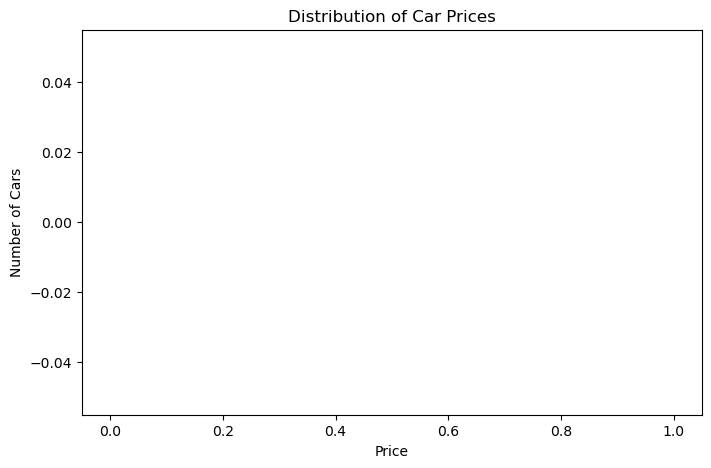

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(data["Price"], bins=30)
plt.title("Distribution of Car Prices")
plt.xlabel("Price")
plt.ylabel("Number of Cars")
plt.show()

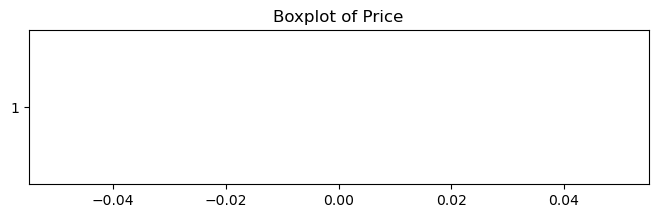

In [53]:
plt.figure(figsize=(8,2))
plt.boxplot(data["Price"], vert=False)
plt.title("Boxplot of Price")
plt.show()

In [54]:
data.sort_values(by="Price", ascending=False).head(10)

,company,year,Price,kms_driven,fuel_type,model


In [55]:
data["Price"].max()

nan

In [56]:
data = data[data["Price"] < 8000000]

In [57]:
data.shape

(0, 6)

In [58]:
data["company"].value_counts()

Series([], Name: count, dtype: int64)

IndexError: index 0 is out of bounds for axis 0 with size 0

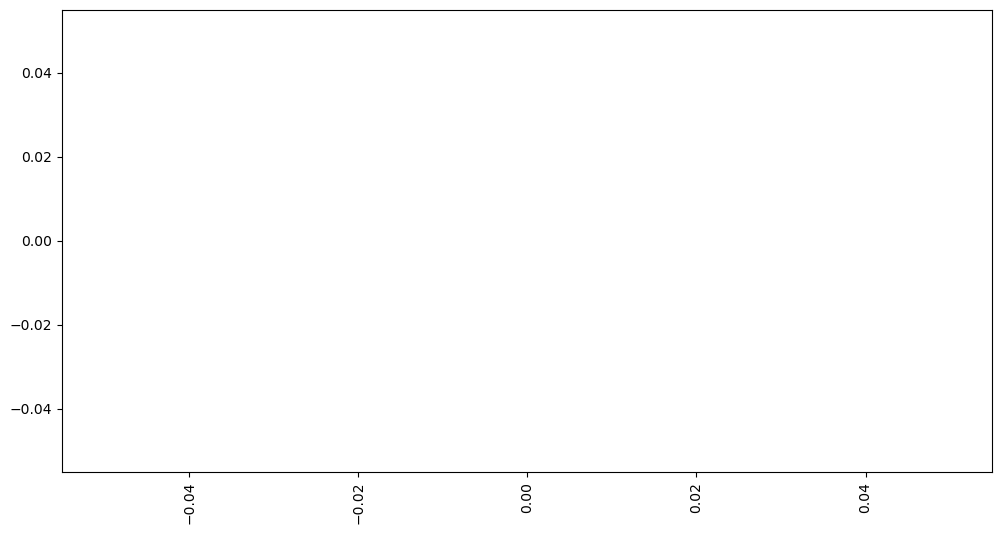

In [59]:
plt.figure(figsize=(12,6))

data["company"].value_counts().plot(kind="bar")

plt.title("Number of Cars by Company")
plt.xlabel("Company")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

In [ ]:
data.groupby("company")["Price"].mean().sort_values(ascending=False)

In [ ]:
data["fuel_type"].value_counts()

In [ ]:
plt.figure(figsize=(6,4))

data["fuel_type"].value_counts().plot(kind="bar")

plt.title("Fuel Type Distribution")
plt.xlabel("Fuel Type")
plt.ylabel("Count")

plt.show()

In [ ]:
data.groupby("fuel_type")["Price"].mean()

In [ ]:
plt.figure(figsize=(10,5))

plt.scatter(data["year"], data["Price"])

plt.title("Year vs Price")
plt.xlabel("Year")
plt.ylabel("Price")

plt.show()

In [ ]:
plt.figure(figsize=(10,5))

plt.scatter(data["kms_driven"], data["Price"])

plt.title("Kilometers Driven vs Price")
plt.xlabel("Kilometers Driven")
plt.ylabel("Price")

plt.show()

In [ ]:
plt.figure(figsize=(14,6))

data.boxplot(column="Price", by="company", rot=90)

plt.title("Company vs Price")
plt.suptitle("")   # Removes extra title
plt.xlabel("Company")
plt.ylabel("Price")

plt.show()

In [ ]:
plt.figure(figsize=(6,5))

data.boxplot(column="Price", by="fuel_type")

plt.title("Fuel Type vs Price")
plt.suptitle("")
plt.xlabel("Fuel Type")
plt.ylabel("Price")

plt.show()

# **ML - Feature Selection**

In [ ]:
X = data.drop("Price", axis=1)

y = data["Price"]

print(X.head())
print()
print(y.head())
print()
print(X.shape)
print(y.shape)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

In [ ]:
categorical_features = ["company", "fuel_type", "model"]

numeric_features = ["year", "kms_driven"]

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "num",
            "passthrough",
            numeric_features
        )
    ]
)

In [ ]:
preprocessor

In [ ]:
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

In [ ]:
pipeline

In [ ]:
pipeline.fit(X_train, y_train)

In [ ]:
y_pred = pipeline.predict(X_test)

print(y_pred[:10])

In [ ]:
comparison = X_test.copy()

comparison["Actual Price"] = y_test.values
comparison["Predicted Price"] = y_pred.astype(int)

comparison.head(10)

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE :", round(mae, 2))
print("MSE :", round(mse, 2))
print("RMSE:", round(rmse, 2))
print("R2 Score:", round(r2, 4))

# **Now...there Linear Regressor model is failed...because** 

**Reason 1: Linear Regression assumes a linear relationship.**

It assumes:

Year ↑  → Price ↑ (Straight Line)

KM ↑    → Price ↓ (Straight Line)

But in reality:

Luxury brands behave differently.
Some models hold their value much better.
Price doesn't always change in a straight line.

========================================================================

**Reason 2: Company and Model**

Look at these predictions:

Actual	Predicted
135000	76281
245000	440547

The model makes some large errors.

Why?

Because model names like:

Swift Dzire
City
EcoSport
Creta

have very different resale values.

Linear Regression struggles to capture these complex relationships.

============================================================================================================

**Reason 3: Outliers**

Even after removing the ₹85 lakh Mahindra, there are still very expensive luxury cars like:

Audi
BMW
Jaguar
Mercedes

These influence the regression line.

# **Next Model: Decision Tree Regressor**

In [ ]:
from sklearn.tree import DecisionTreeRegressor

In [ ]:
dt_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeRegressor(random_state=42))
    ]
)

In [ ]:
dt_pipeline.fit(X_train, y_train)

In [ ]:
dt_pred = dt_pipeline.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, dt_pred)
rmse = mean_squared_error(y_test, dt_pred) ** 0.5
r2 = r2_score(y_test, dt_pred)

print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))
print("R2 Score:", round(r2,4))

**DT-ML-Model  also failed...because**

MAE improved, but R² became worse?

Yes!

This is why we never judge a model using only one metric.

# **Next Model  is (Random Forest)**

In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=200,
                random_state=42
            )
        )
    ]
)

In [ ]:
rf_pipeline.fit(X_train, y_train)

In [ ]:
rf_pred = rf_pipeline.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, rf_pred)
rmse = mean_squared_error(y_test, rf_pred) ** 0.5
r2 = r2_score(y_test, rf_pred)

print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))
print("R2 :", round(r2,4))

In [ ]:
import joblib

# joblib.dump(pipeline, "car_price_prediction_pipeline.joblib")

In [ ]:
loaded_model = joblib.load("car_price_prediction_pipeline.joblib")

In [ ]:
import pandas as pd

sample_car = pd.DataFrame({
    "company": ["Hyundai"],
    "year": [2018],
    "kms_driven": [45000],
    "fuel_type": ["Petrol"],
    "model": ["Grand i10 Magna 1.2 Kappa VTVT"]
})

In [ ]:
prediction = loaded_model.predict(sample_car)

print("Predicted Price:", int(prediction[0]))